<a href="https://colab.research.google.com/github/Raksh1707/Datamining_project/blob/main/datamining4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
from google.colab import files
uploaded = files.upload()


Saving studentttttttttttt.csv to studentttttttttttt.csv


In [3]:
df=pd.read_csv('studentttttttttttt.csv')
df.head()

,Student_ID,Gender,Attendance,Assignment_Score,Participation,Midterm_Score,Final_Score,Study_Hours,At_Risk
0,S001,Male,92,88,9,84,86,15,No
1,S002,Female,85,79,8,76,78,12,No
2,S003,Male,68,60,5,58,56,6,Yes
3,S004,Female,95,94,10,92,95,18,No
4,S005,Male,72,65,6,62,64,8,Yes


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Student_ID        50 non-null     object
 1   Gender            50 non-null     object
 2   Attendance        50 non-null     int64 
 3   Assignment_Score  50 non-null     int64 
 4   Participation     50 non-null     int64 
 5   Midterm_Score     50 non-null     int64 
 6   Final_Score       50 non-null     int64 
 7   Study_Hours       50 non-null     int64 
 8   At_Risk           50 non-null     object
dtypes: int64(6), object(3)
memory usage: 3.6+ KB
None


In [5]:
print(df.isnull().sum())


Student_ID          0
Gender              0
Attendance          0
Assignment_Score    0
Participation       0
Midterm_Score       0
Final_Score         0
Study_Hours         0
At_Risk             0
dtype: int64


In [6]:
df.drop_duplicates(inplace=True)


In [7]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [8]:
print(df.describe())

       Student_ID     Gender  Attendance  Assignment_Score  Participation  \
count    50.00000  50.000000   50.000000         50.000000      50.000000   
mean     24.50000   0.500000   78.920000         74.220000       7.040000   
std      14.57738   0.505076   11.750536         14.006252       2.079639   
min       0.00000   0.000000   57.000000         48.000000       3.000000   
25%      12.25000   0.000000   69.250000         61.250000       5.000000   
50%      24.50000   0.500000   79.500000         75.500000       7.000000   
75%      36.75000   1.000000   88.750000         85.750000       9.000000   
max      49.00000   1.000000   98.000000         97.000000      10.000000   

       Midterm_Score  Final_Score  Study_Hours    At_Risk  
count      50.000000    50.000000    50.000000  50.000000  
mean       72.100000    73.800000    10.900000   0.320000  
std        14.370108    15.072613     4.625793   0.471212  
min        46.000000    47.000000     4.000000   0.000000  
25%   

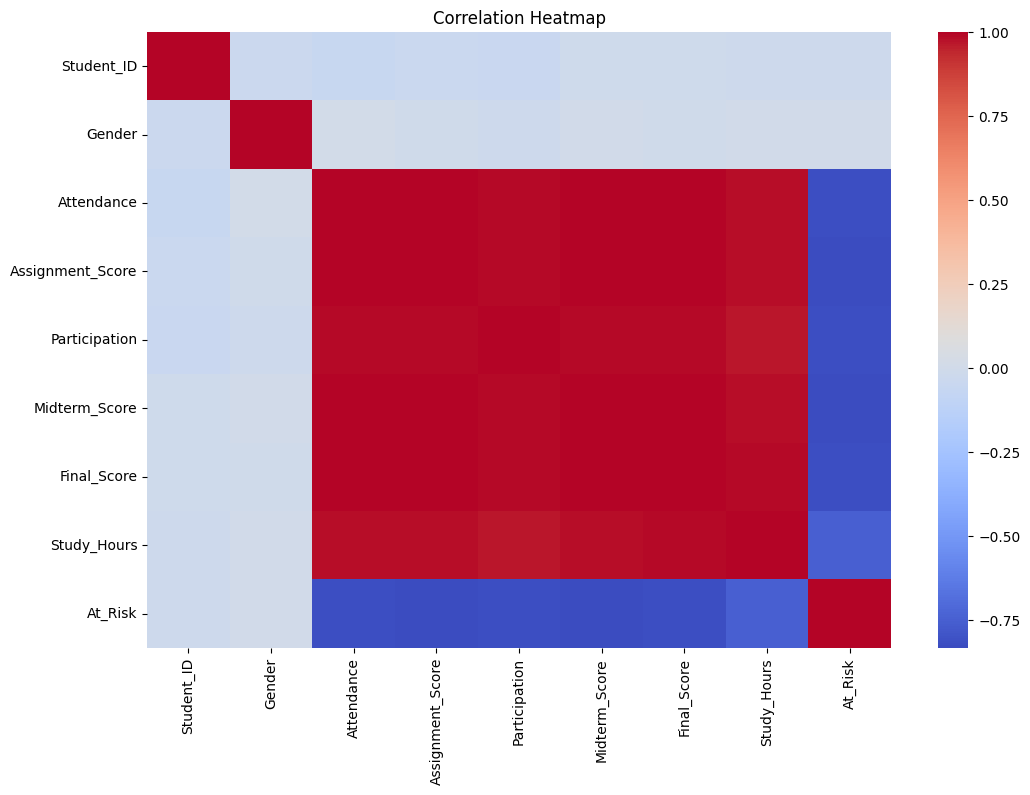

In [9]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

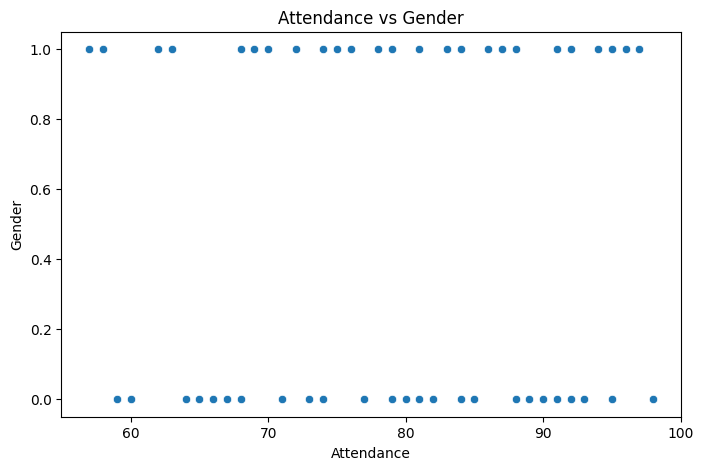

In [15]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Attendance',
    y='Gender',
    data=df
)

plt.title("Attendance vs Gender")
plt.show()

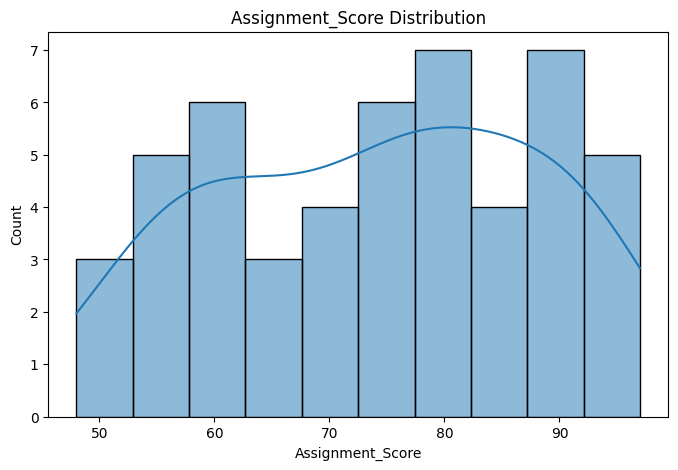

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df['Assignment_Score'],
             bins=10,
             kde=True)

plt.title("Assignment_Score Distribution")
plt.show()


In [17]:
def risk_level(score):

    if score < 40:
        return "High Risk"

    elif score < 60:
        return "Medium Risk"

    else:
        return "Low Risk"


df['At_Risk'] = df['Attendance'].apply(risk_level)

print("\nStudent Risk Categories:")
print(df[['Student_ID','Attendance','At_Risk']])



Student Risk Categories:
    Student_ID  Attendance      At_Risk
0            0          92     Low Risk
1            1          85     Low Risk
2            2          68     Low Risk
3            3          95     Low Risk
4            4          72     Low Risk
5            5          89     Low Risk
6            6          78     Low Risk
7            7          60     Low Risk
8            8          97     Low Risk
9            9          81     Low Risk
10          10          75     Low Risk
11          11          66     Low Risk
12          12          88     Low Risk
13          13          91     Low Risk
14          14          70     Low Risk
15          15          84     Low Risk
16          16          58  Medium Risk
17          17          93     Low Risk
18          18          79     Low Risk
19          19          65     Low Risk
20          20          87     Low Risk
21          21          82     Low Risk
22          22          74     Low Risk
23          23

In [21]:
#
X = df.drop('At_Risk', axis=1)
y = df['At_Risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [24]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [25]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))


Accuracy: 1.0

Classification Report
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00         9
 Medium Risk       1.00      1.00      1.00         1

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



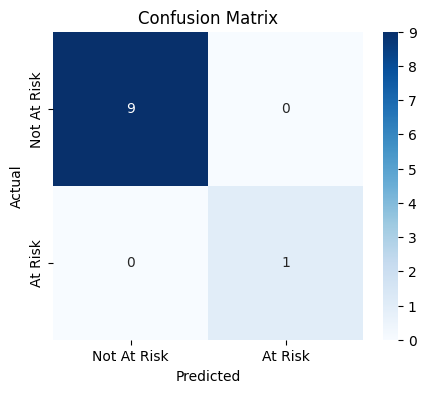

In [26]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Not At Risk','At Risk'],
            yticklabels=['Not At Risk','At Risk'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

            Feature  Importance
2        Attendance    0.262532
5     Midterm_Score    0.226463
3  Assignment_Score    0.172482
6       Final_Score    0.164405
7       Study_Hours    0.079474
4     Participation    0.069680
0        Student_ID    0.016322
1            Gender    0.008643


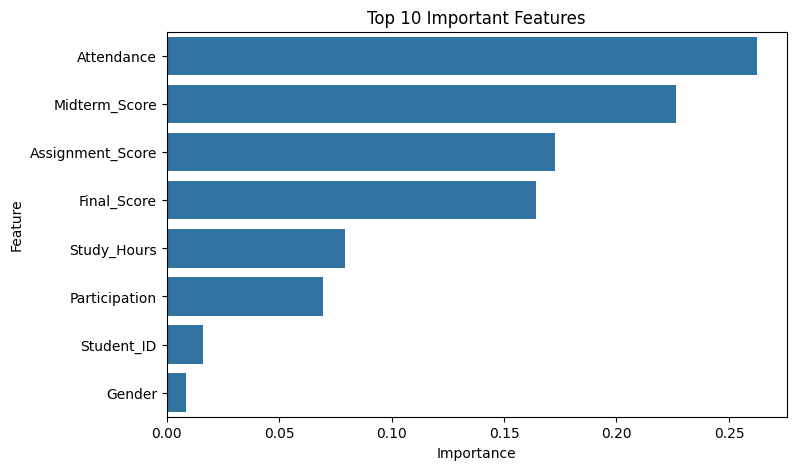

In [27]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

print(importance.head(10))

plt.figure(figsize=(8,5))
sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)
plt.title("Top 10 Important Features")
plt.show()


In [28]:
risk_students = df[df['At_Risk']==1]

print("\nNumber of At-Risk Students:", len(risk_students))

print(risk_students.head())

# Save Report
risk_students.to_csv("At_Risk_Students.csv", index=False)

print("Report Saved Successfully")


Number of At-Risk Students: 0
Empty DataFrame
Columns: [Student_ID, Gender, Attendance, Assignment_Score, Participation, Midterm_Score, Final_Score, Study_Hours, At_Risk]
Index: []
Report Saved Successfully
